<a href="https://colab.research.google.com/github/lord-of-the-strings/Data-Science/blob/main/01_monte_carlo_finance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd

In [6]:
initial_money=500000
years=30
simulations=1000
avg_return=0.08
volatility=0.15

In [8]:
year1_returns=np.random.normal(avg_return,volatility,simulations)
print(year1_returns[:5])

[ 0.13325791 -0.15035698  0.17196231 -0.36449471  0.01132089]


In [9]:
year1_balances=initial_money*(1+year1_returns)
print(year1_balances[:5])

[566628.95439858 424821.50807949 585981.15650618 317752.64670601
 505660.44579447]


In [11]:
grid=np.zeros((years,simulations))
grid[0]=initial_money

In [12]:
for t in range(1,years):
  this_returns=np.random.normal(avg_return,volatility,simulations)
  prev_money=grid[t-1]
  grid[t]=prev_money*(1+this_returns)

In [13]:
final_bal=grid[-1]
sorted_bal=np.sort(final_bal)
print(f"Worst-case universe (Unluckiest): ${sorted_bal[0]:,.2f}")
print(f"Middle-case universe (Average luck): ${sorted_bal[500]:,.2f}")
print(f"Best-case universe (Luckiest): ${sorted_bal[-1]:,.2f}")

Worst-case universe (Unluckiest): $240,523.06
Middle-case universe (Average luck): $3,587,614.32
Best-case universe (Luckiest): $47,185,891.71


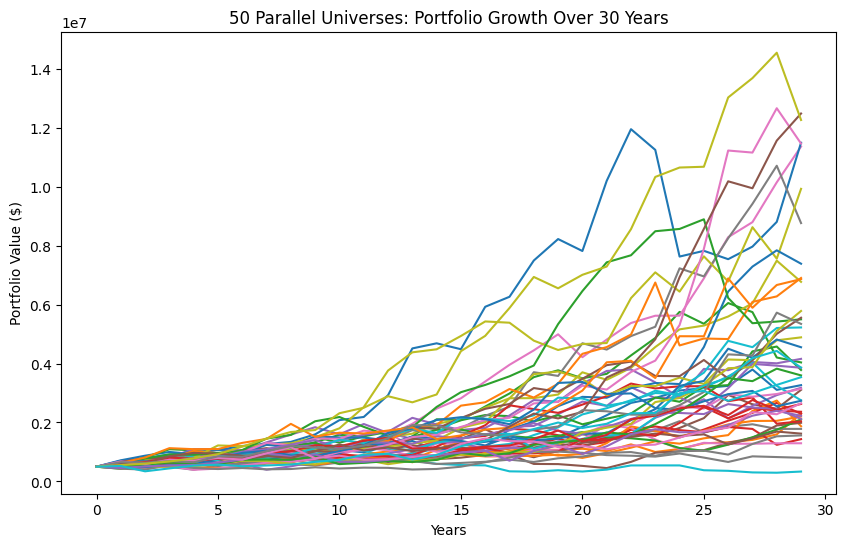

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(grid[:,:50])
plt.title("50 Parallel Universes: Portfolio Growth Over 30 Years")
plt.xlabel("Years")
plt.ylabel("Portfolio Value ($)")
plt.show()

In [15]:
worst_case = np.percentile(final_bal, 10)
most_likely = np.percentile(final_bal, 50)
best_case = np.percentile(final_bal, 90)

In [16]:
print(f"Worst-Case (10th Percentile): ${worst_case:,.2f}")
print(f"Most Likely (50th Percentile): ${most_likely:,.2f}")
print(f"Best-Case (90th Percentile): ${best_case:,.2f}")

Worst-Case (10th Percentile): $1,279,831.51
Most Likely (50th Percentile): $3,576,977.62
Best-Case (90th Percentile): $9,718,213.98


In [17]:
successful=np.sum(final_bal>=1000000)
probability=(successful/simulations)*100
print(f"Out of 1,000 parallel universes, {successful} hit the $1M goal.")
print(f"Probability of reaching the goal: {probability}%")

Out of 1,000 parallel universes, 948 hit the $1M goal.
Probability of reaching the goal: 94.8%


In [22]:
#With annual contribution
grid=np.zeros((years,simulations))
grid[0]=initial_money
annual_contribution=10000
for t in range(1,years):
  returns_this_year = np.random.normal(avg_return, volatility, simulations)
  previous_year = grid[t - 1]
  grid[t]=(previous_year*(1+returns_this_year))+annual_contribution
  annual_contribution*=1.03 #inflation adjustment 3%

In [23]:
final_bal = grid[-1]
successful=np.sum(final_bal>1000000)
probability=(successful/simulations)*100
print(f"New Worst-Case (10th Percentile): ${np.percentile(final_bal, 10):,.2f}")
print(f"New Most Likely (50th Percentile): ${np.percentile(final_bal, 50):,.2f}")
print(f"New Probability of reaching the goal: {probability}%")

New Worst-Case (10th Percentile): $2,004,299.35
New Most Likely (50th Percentile): $4,808,859.19
New Probability of reaching the goal: 99.3%
